# Advanced rendering

In [11]:
import mujoco
import mediapy as media
import numpy as np
from matplotlib import pyplot as plt
import itertools

In [2]:
model = mujoco.MjModel.from_xml_path('adv_render.xml')
data = mujoco.MjData(model)

""

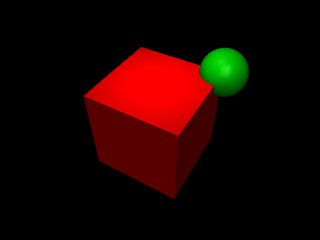

In [3]:
with mujoco.Renderer(model) as renderer:
    mujoco.mj_forward(model, data)
    renderer.update_scene(data)
    media.show_image(renderer.render())

## Enable transparency and frame visualization

""

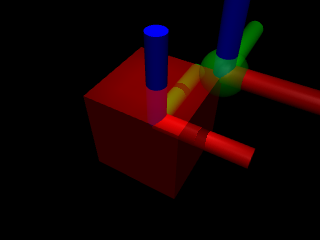

In [6]:
scene_option = mujoco.MjvOption()
scene_option.frame = mujoco.mjtFrame.mjFRAME_GEOM
scene_option.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = True

with mujoco.Renderer(model) as renderer:
    renderer.update_scene(data, scene_option=scene_option)
    frame = renderer.render()
    media.show_image(frame)

## Depth rendering

""

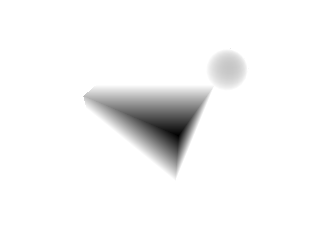

In [8]:
with mujoco.Renderer(model) as renderer:
    # update renderer to render depth
    renderer.enable_depth_rendering()

    # reset the scene
    renderer.update_scene(data)

    # depth is a float array, in meters???
    depth = renderer.render()

    # shift nearest values to the origin
    depth -= depth.min()
    # Scale by 2 mean distances of near rays???
    depth /= depth[depth <= 1].mean()
    # scale to [0 255]
    pixels = 255*np.clip(depth, 0 , 1)

    media.show_image(pixels.astype(np.uint8))

## segmentation rendering

""

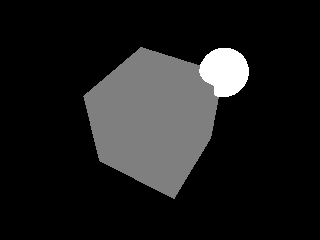

In [10]:
with mujoco.Renderer(model) as renderer:
    renderer.disable_depth_rendering()

    # Update renderer to render segmentation
    renderer.enable_segmentation_rendering()

    # Reset the scene
    renderer.update_scene(data)

    seg = renderer.render()

    # Display the contents of the first channel which contains
    # Object IDs. 
    # The second channel, seg[:, :, 1], contains object types
    geom_ids = seg[:, :, 0]
    # Infinity is mapped to -1
    geom_ids = geom_ids.astype(np.float64) + 1 
    # Scale to [0 1]
    geom_ids /= geom_ids.max()
    pixels = 255*geom_ids
    media.show_image(pixels.astype(np.uint8))


## The camera matrix

In [13]:
def compute_camera_matrix(renderer, data):
    """Returns the [3x4] camera matrix."""
    # If the camera is a 'free' camera we get its position 
    # and orientation from the scene data structure. it is
    # a stereo camera, so we average over the left and right
    #  channels. Note: we call 'self.update()' in order to
    # ensure that the contents of "scene.camera" are correct.
    renderer.update_scene(data)
    pos = np.mean([camera.pos for camera in renderer.scene.camera], axis=0)
    z = -np.mean([camera.forward for camera in renderer.scene.camera], axis=0)
    y = np.mean([camera.up for camera in renderer.scene.camera], axis=0)
    rot = np.vstack((np.cross(y, z), y, z))
    fov = model.vis.global_.fovy

    # Translation matrix (4x4)
    translation = np.eye(4)
    translation[0:3,3] = -pos

    # Rotation matrix (4x4)
    rotation = np.eye(4)
    rotation[0:3,0:3] = rot

    # Focal transformation matrix (4x4)
    focal_scaling = (1/np.tan(np.deg2rad(fov)/2)*renderer.height / 2.0)
    focal = np.diag([-focal_scaling, focal_scaling, 1.0, 0.0])[0:3, :]

    # Image matrix (3x3)
    image = np.eye(3)
    image[0,2] = (renderer.width -1) /2.0
    image[1,2] = (renderer.height -1) /2.0
    return image @ focal @ rotation @ translation

## project from world to camera coordinates

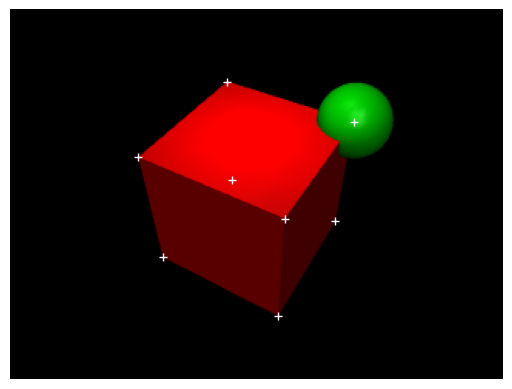

In [14]:
with mujoco.Renderer(model) as renderer:
    renderer.disable_segmentation_rendering()
    # reset the scene
    renderer.update_scene(data)

    # get the world corrdinates of the box corner
    box_pos = data.geom_xpos[model.geom('red_box').id]
    box_mat = data.geom_xmat[model.geom('red_box').id].reshape(3, 3)
    box_size = model.geom_size[model.geom('red_box').id]
    offsets = np.array([-1, 1]) * box_size[:,None]
    xyz_local = np.stack(list(itertools.product(*offsets))).T
    xyz_global = box_pos[:, None] + box_mat @ xyz_local

    # Camera matrices multiply homogenous [x, y, z, 1] vectors
    corners_homogeneous = np.ones((4, xyz_global.shape[1]), dtype=float)
    corners_homogeneous[:3, :] = xyz_global

    # Get the camera matrix.
    m = compute_camera_matrix(renderer, data)

    # Project world coordinates into pixel space
    # https://en.wikipedia.org/wiki/3D_projection#Mathematical_formula
    xs, ys, s = m @ corners_homogeneous
    # x and y are in pixel coordinate system
    x = xs / s
    y = ys / s

    # Render the camera view and overlay the projected corner coordinates
    pixels = renderer.render()
    fig, ax = plt.subplots(1,1)
    ax.imshow(pixels)
    ax.plot(x, y, '+', c='w')
    ax.set_axis_off()


## Modifying the scene

In [16]:
def get_geom_speed(model, data, geom_name):
    """Returens the speed of a geom."""
    geom_vel = np.zeros(6)
    geom_type = mujoco.mjtObj.mjOBJ_GEOM
    geom_id = data.geom(geom_name).id
    mujoco.mj_objectVelocity(model, data, geom_type, geom_id, geom_vel, 0)
    return np.linalg.norm(geom_vel)

def add_visual_capsule(scene, point1, point2, radius, rgba):
    """ adds one capsule to a mjvScene."""
    if scene.ngeom >= scene.maxgeom:
        return
    scene.ngeom += 1 #increment ngeom
    # Initalise a new capsule, and add it to the scene using mjv_connector
    mujoco.mjv_initGeom(scene.geoms[scene.ngeom-1],
                        mujoco.mjtGeom.mjGEOM_CAPSULE, np.zeros(3),
                        np.zeros(3), np.zeros(9), rgba.astype(np.float32))
    mujoco.mjv_connector(scene.geoms[scene.ngeom-1],
                         mujoco.mjtGeom.mjGEOM_CAPSULE, radius,
                         point1, point2)
    
# Traces of time, postion and speed
times = []
positions = []
speeds = []
offset = model.jnt_axis[0]/16 # offset along the joint axis

def modify_scene(scn):
    """draw position trace, speed modifies width and colors."""
    if len(positions) > 1:
        for i in range(len(positions)-1):
            rgba = np.array((np.clip(speeds[i]/10, 0 ,1),
                                np.clip(1-speeds[i]/10, 0, 1),
                                .5, 1.0))
            radius = .003*(1+speeds[i])
            point1 = positions[i] + offset*times[i]
            point2 = positions[i+1] + offset*times[i+1]
            add_visual_capsule(scn, point1, point2, radius, rgba)

duration = 6 # seconds
framerate = 30 # Hz

#Simulate and display video
frames = []

# Reset state and time
mujoco.mj_resetData(model,data)
mujoco.mj_forward(model,data)

with mujoco.Renderer(model) as renderer:
    while data.time < duration:
        # append data to the traces
        positions.append(data.geom_xpos[data.geom("green_sphere").id].copy())
        times.append(data.time)
        speeds.append(get_geom_speed(model, data, "green_sphere"))
        mujoco.mj_step(model, data)
        if len(frames) < duration*framerate:
            renderer.update_scene(data)
            modify_scene(renderer.scene)
            pixels = renderer.render()
            frames.append(pixels)

media.show_video(frames, fps=framerate)


This browser does not support the video tag.


In [47]:
def get_geom_speed(model, data, geom_name):
    """Returens the speed of a geom."""
    geom_vel = np.zeros(6)
    geom_type = mujoco.mjtObj.mjOBJ_GEOM
    geom_id = data.geom(geom_name).id
    mujoco.mj_objectVelocity(model, data, geom_type, geom_id, geom_vel, 0)
    return np.linalg.norm(geom_vel)

def add_visual_capsule(scene, point1, point2, radius, rgba):
    """ adds one capsule to a mjvScene."""
    if scene.ngeom >= scene.maxgeom:
        return
    scene.ngeom += 1 #increment ngeom
    # Initalise a new capsule, and add it to the scene using mjv_connector
    mujoco.mjv_initGeom(scene.geoms[scene.ngeom-1],
                        mujoco.mjtGeom.mjGEOM_CAPSULE, np.zeros(3),
                        np.zeros(3), np.zeros(9), rgba.astype(np.float32))
    mujoco.mjv_connector(scene.geoms[scene.ngeom-1],
                         mujoco.mjtGeom.mjGEOM_CAPSULE, radius,
                         point1, point2)
    
# Traces of time, postion and speed
times = []
positions = []
speeds = []
offset = model.jnt_axis[0]/16 # offset along the joint axis

def modify_scene(scn):
    """draw position trace, speed modifies width and colors."""
    if len(positions) > 1:
        for i in range(len(positions)-1):
            rgba = np.array((np.clip(speeds[i]/10, 0 ,1),
                                np.clip(1-speeds[i]/10, 0, 1),
                                .5, 1.0))
            radius = .003*(1+speeds[i])
            point1 = positions[i] + offset*times[i]
            point2 = positions[i+1] + offset*times[i+1]
            add_visual_capsule(scn, point1, point2, radius, rgba)

duration = 12 # seconds
framerate = 30 # Hz

#Simulate and display video
frames = []

# Reset state and time
mujoco.mj_resetData(model,data)
mujoco.mj_forward(model,data)

scene_option2 = mujoco.MjvOption()
scene_option2.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = True

with mujoco.Renderer(model) as renderer:
    while data.time < 1.0:
        if len(frames) % 30 == 0:
            # print(len(frames))
            # print(len(frames) % 30)
            # print(data.time)
            # append data to the traces
            positions.append(data.geom_xpos[data.geom("green_sphere").id].copy())
            times.append(data.time)
            speeds.append(get_geom_speed(model, data, "green_sphere"))
        mujoco.mj_step(model, data)
        if len(frames) < duration*framerate:
            renderer.update_scene(data, scene_option=scene_option2)
            modify_scene(renderer.scene)
            pixels = renderer.render()
            frames.append(pixels)

media.show_video(frames, fps=framerate)


This browser does not support the video tag.


## Multiple frames in the same scene

In [60]:
import os

# Path
path = '../../model/humanoid/humanoid.xml'

# Check if its a file
if os.path.isfile(path):
    print("File exists.")
else:
    print("File does not exist.")
# Check if the directory exists
if os.path.isdir(path):
    print("Directory exists. Listing contents:")
    for item in os.listdir(path):
        print(item)
else:
    print("Directory does not exist.")

File exists.
Directory does not exist.


In [65]:
# Get MuJoCo's standard humaniod model
model = mujoco.MjModel.from_xml_path('../../model/humanoid/humanoid.xml')
data = mujoco.MjData(model)
data2 = mujoco.MjData(model)

# Episode parameters
duration = 3  # seconds
framerate = 60 #Hz
data.qpos[0:2] = [-.5, -.5] # initial x y position in meters
data.qvel[2] = 4 # Initial vertical velocity in m/s
ctrl_phase = 2 * np.pi * np.random.rand(model.nu) # Control Phase???
ctrl_freq = 1 # Control frequency

# Visual options for the "ghost" model.actuator
vopt2 = mujoco.MjvOption()
vopt2.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = True
pert = mujoco.MjvPerturb() # empthy MjvPerturb object???
# We only want dynamic objects ( the humanoid). Static objects (the floor)
# should not be re-drawn. the mjtCatBit flag lets us do that,
# though we could equivalently use mjtVisFlag.mjVIS_STATIC
catmask = mujoco.mjtCatBit.mjCAT_DYNAMIC

# Simulate and render
frames = []
with mujoco.Renderer(model, 480, 640) as renderer:
    while data.time < duration:
        # Sinusoidal control signal
        data.ctrl = np.sin(ctrl_phase + 2 * np.pi * data.time * ctrl_freq)
        mujoco.mj_step(model, data)
        if len(frames) < data.time*framerate:
            # draw the regular humanoid  from 'data'
            renderer.update_scene(data)

            # Copy qpos to data2, move the humanoid sideways, and call mj_forward
            data2.qpos = data.qpos
            data2.qpos[0] += 1.5
            data2.qpos[1] += 1
            mujoco.mj_forward(model, data2)

            # cal mjv_addGeoms to add the ghost humanoid to the scene
            mujoco.mjv_addGeoms(model, data2, vopt2, pert, catmask, renderer.scene)

            # Render and add the frame
            pixels = renderer.render()
            frames.append(pixels)

# Render the video at half real-time
media.show_video(frames, fps=framerate/2)



This browser does not support the video tag.


## camera control

In [109]:
model = mujoco.MjModel.from_xml_path('dominos.xml')
data = mujoco.MjData(model)

### Render from fixed camera

In [99]:
model = mujoco.MjModel.from_xml_path('dominos.xml')
data = mujoco.MjData(model)

duration = 2.5 #seconds
framerate = 60 #Hz
slowdown = 4 # 4x slowdown
height = 1020
width = 1440

# Simulate and display video
frames = []
mujoco.mj_resetData(model, data) # reset the state and time
with mujoco.Renderer(model, height, width) as renderer:
    while data.time < duration:
        mujoco.mj_step(model, data)
        if len(frames) < data.time*framerate*slowdown:
            renderer.update_scene(data, camera='top')
            pixels = renderer.render()
            frames.append(pixels)
media.show_video(frames, fps=framerate)
            

This browser does not support the video tag.


### Render from moving camera

In [110]:
model = mujoco.MjModel.from_xml_path('dominos.xml')
data = mujoco.MjData(model)

duration = 3 # seconds
height = 1024
width= 1440

# find time when box is thrown (speed > 2cm/s)
throw_time = 0.0
mujoco.mj_resetData(model, data)
while data.time < duration and not throw_time:
    mujoco.mj_step(model, data)
    box_speed = np.linalg.norm(data.joint('box').qvel[:3])
    if box_speed > 0.02:
        throw_time = data.time
assert throw_time > 0

def mix(time, t0=0.0, width=1.0):
    """Sigmoidal mixing function"""
    t = (time-t0)/width
    s = 1/(1+np.exp(-t))
    return 1-s, s

def unit_cos(t):
    """ Unit cosing sigmoid from (0 0 to (1 1)"""
    return 0.5 - np.cos(np.pi*np.clip(t, 0, 1))/2

def orbit_motion(t):
    """ Return orbit trajectory"""
    distance = 0.9
    azimuth = 140 + 100 * unit_cos(t)
    elevation = -30
    lookat = data.geom('floor').xpos.copy()
    return distance, azimuth, elevation, lookat

def track_motion():
    """ return box track trajectory"""
    distance = 0.08
    azimuth = 280
    elevation = -10
    lookat = data.geom('box').xpos.copy()
    return distance, azimuth, elevation, lookat

def cam_motion():
    """Return sigmoidally mixed {orbit, box-track} trajectory"""
    d0, a0, e0, l0 = orbit_motion(data.time / throw_time)
    d1, a1, e1, l1 = track_motion()
    mix_time = 0.3
    w0, w1 = mix(data.time, throw_time, mix_time)
    return (w0*d0 + w1*d1, w0*a0+w1*a1, w0*e0+w1*e1, w0*l0+w1*l1)

# Make a camera
cam = mujoco.MjvCamera()
mujoco.mjv_defaultCamera(cam)

# Simulate and display video
framerate = 60 # HZ
slowdown = 4 # 4x slow motion
mujoco.mj_resetData(model, data)
frames = []
with mujoco.Renderer(model, height, width) as renderer:
    while data.time < duration:
        mujoco.mj_step(model, data)
        if (len(frames) < data.time*framerate*slowdown):
            cam.distance, cam.azimuth, cam.elevation, cam.lookat = cam_motion()
            renderer.update_scene(data, camera=cam)
            pixels = renderer.render()
            frames.append(pixels)
media.show_video(frames, fps=framerate)


This browser does not support the video tag.
